In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df1 = pd.read_csv('One_year_compiled.csv')

# Ejercicio 1

In [2]:
df1.columns

Index(['timestamp', 'pCut::Motor_Torque',
       'pCut::CTRL_Position_controller::Lag_error',
       'pCut::CTRL_Position_controller::Actual_position',
       'pCut::CTRL_Position_controller::Actual_speed',
       'pSvolFilm::CTRL_Position_controller::Actual_position',
       'pSvolFilm::CTRL_Position_controller::Actual_speed',
       'pSvolFilm::CTRL_Position_controller::Lag_error', 'pSpintor::VAX_speed',
       'month', 'day', 'hour', 'sample_Number', 'mode'],
      dtype='str')

In [3]:
df1['mode'].unique()

<StringArray>
['mode1', 'mode2', 'mode5', 'mode3', 'mode4', 'mode8', 'mode6', 'mode7']
Length: 8, dtype: str

In [4]:
df1.head()

,timestamp,pCut::Motor_Torque,pCut::CTRL_Position_controller::Lag_error,pCut::CTRL_Position_controller::Actual_position,pCut::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Actual_position,pSvolFilm::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Lag_error,pSpintor::VAX_speed,month,day,hour,sample_Number,mode
0,0.008,0.199603,0.027420,628392628,-920.104980,5298555,2441.235352,0.899543,1379.999756,1,4,184148.0,0.0,mode1
1,0.012,0.281624,0.002502,628392625,-937.271118,5298565,2453.819092,0.874072,1379.999756,1,4,184148.0,0.0,mode1
2,0.016,0.349315,-0.018085,628392621,-951.004028,5298575,2476.469727,0.879806,1379.999756,1,4,184148.0,0.0,mode1
3,0.020,0.444450,-0.054680,628392617,-1019.668579,5298585,2501.637207,0.837500,1379.999756,1,4,184148.0,0.0,mode1
4,0.024,0.480923,-0.042770,628392613,-1023.101807,5298595,2519.254395,0.905347,1379.999756,1,4,184148.0,0.0,mode1


In [5]:
# pd.set_option('display.float_format', '{:.2f}'.format)
df1.describe().round(3)

,timestamp,pCut::Motor_Torque,pCut::CTRL_Position_controller::Lag_error,pCut::CTRL_Position_controller::Actual_position,pCut::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Actual_position,pSvolFilm::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Lag_error,pSpintor::VAX_speed,month,day,hour,sample_Number
count,1062912.000,1062912.000,1062912.000,1.062912e+06,1062912.000,1.062912e+06,1062912.000,1062912.000,1062912.000,1062912.000,1062912.000,1062912.000,1062912.000
mean,4.102,-0.121,-0.000,3.371415e+08,1945.795,1.488169e+08,5367.032,0.985,1927.328,5.268,16.536,136187.983,258.874
std,2.365,0.608,0.121,5.466868e+08,4873.922,2.711355e+08,3382.194,0.344,655.905,3.503,8.488,32252.987,149.749
min,0.004,-6.560,-1.888,-2.039056e+09,-9482.574,1.936250e+05,-20.134,-0.914,0.000,1.000,1.000,81158.000,0.000
25%,2.056,-0.370,-0.022,8.626082e+07,-1908.875,2.136702e+07,3032.669,0.838,1500.000,2.000,9.000,111317.000,129.000
50%,4.104,-0.119,0.001,1.919407e+08,2595.520,7.259557e+07,4582.979,0.971,1800.000,4.000,18.000,134818.000,259.000
75%,6.152,0.255,0.024,5.691639e+08,5441.666,1.602507e+08,5823.731,1.106,2280.000,8.000,23.000,161827.000,389.000
max,8.200,3.857,2.022,1.911789e+09,17928.312,1.453671e+09,17972.023,3.568,3600.000,12.000,31.000,223249.000,518.000


In [6]:
# pd.set_option('display.max_rows', None)
df1['hour'].value_counts(ascending=True)

hour
185909.0    1530
184148.0    2049
184424.0    2049
184835.0    2049
185047.0    2049
            ... 
151444.0    2049
155353.0    2049
183459.0    2049
121536.0    4098
113211.0    4098
Name: count, Length: 517, dtype: int64

# Ejercicio 3

In [7]:
df1_copia = df1.copy()
df1_copia = np.round(df1_copia, 1)
df1_copia

,timestamp,pCut::Motor_Torque,pCut::CTRL_Position_controller::Lag_error,pCut::CTRL_Position_controller::Actual_position,pCut::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Actual_position,pSvolFilm::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Lag_error,pSpintor::VAX_speed,month,day,hour,sample_Number,mode
0,0.0,0.2,0.0,628392628,-920.1,5298555,2441.2,0.9,1380.0,1,4,184148.0,0.0,mode1
1,0.0,0.3,0.0,628392625,-937.3,5298565,2453.8,0.9,1380.0,1,4,184148.0,0.0,mode1
2,0.0,0.3,-0.0,628392621,-951.0,5298575,2476.5,0.9,1380.0,1,4,184148.0,0.0,mode1
3,0.0,0.4,-0.1,628392617,-1019.7,5298585,2501.6,0.8,1380.0,1,4,184148.0,0.0,mode1
4,0.0,0.5,-0.0,628392613,-1023.1,5298595,2519.3,0.9,1380.0,1,4,184148.0,0.0,mode1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062907,8.2,-0.3,-0.0,194924473,7220.1,11693928,4610.7,1.0,1500.0,12,28,185909.0,518.0,mode2
1062908,8.2,-0.3,-0.0,194924502,7257.8,11693946,4618.2,1.0,1500.0,12,28,185909.0,518.0,mode2
1062909,8.2,-0.2,-0.0,194924531,7371.1,11693964,4583.0,1.0,1500.0,12,28,185909.0,518.0,mode2
1062910,8.2,-0.4,0.0,194924560,7360.8,11693983,4615.7,1.0,1500.0,12,28,185909.0,518.0,mode2


# Ejercicio 4

In [8]:
df1_copia.select_dtypes(include=["str"])

,mode
0,mode1
1,mode1
2,mode1
3,mode1
4,mode1
...,...
1062907,mode2
1062908,mode2
1062909,mode2
1062910,mode2


# Ejercicio 5

In [9]:
df1.drop(columns=["day"])

,timestamp,pCut::Motor_Torque,pCut::CTRL_Position_controller::Lag_error,pCut::CTRL_Position_controller::Actual_position,pCut::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Actual_position,pSvolFilm::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Lag_error,pSpintor::VAX_speed,month,hour,sample_Number,mode
0,0.008000,0.199603,0.027420,628392628,-920.104980,5298555,2441.235352,0.899543,1379.999756,1,184148.0,0.0,mode1
1,0.012000,0.281624,0.002502,628392625,-937.271118,5298565,2453.819092,0.874072,1379.999756,1,184148.0,0.0,mode1
2,0.016000,0.349315,-0.018085,628392621,-951.004028,5298575,2476.469727,0.879806,1379.999756,1,184148.0,0.0,mode1
3,0.020000,0.444450,-0.054680,628392617,-1019.668579,5298585,2501.637207,0.837500,1379.999756,1,184148.0,0.0,mode1
4,0.024000,0.480923,-0.042770,628392613,-1023.101807,5298595,2519.254395,0.905347,1379.999756,1,184148.0,0.0,mode1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062907,8.179999,-0.277697,-0.023948,194924473,7220.077148,11693928,4610.663086,0.958136,1499.999756,12,185909.0,518.0,mode2
1062908,8.183999,-0.285098,-0.022138,194924502,7257.842773,11693946,4618.213379,0.971821,1499.999756,12,185909.0,518.0,mode2
1062909,8.187999,-0.155192,-0.034412,194924531,7371.139160,11693964,4582.979004,0.981734,1499.999756,12,185909.0,518.0,mode2
1062910,8.191999,-0.371426,0.031594,194924560,7360.839844,11693983,4615.696777,0.987367,1499.999756,12,185909.0,518.0,mode2


# Ejercicio 6

In [10]:
df1_copia["nueva"] = df1_copia["month"].values * 2
df1_copia

,timestamp,pCut::Motor_Torque,pCut::CTRL_Position_controller::Lag_error,pCut::CTRL_Position_controller::Actual_position,pCut::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Actual_position,pSvolFilm::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Lag_error,pSpintor::VAX_speed,month,day,hour,sample_Number,mode,nueva
0,0.0,0.2,0.0,628392628,-920.1,5298555,2441.2,0.9,1380.0,1,4,184148.0,0.0,mode1,2
1,0.0,0.3,0.0,628392625,-937.3,5298565,2453.8,0.9,1380.0,1,4,184148.0,0.0,mode1,2
2,0.0,0.3,-0.0,628392621,-951.0,5298575,2476.5,0.9,1380.0,1,4,184148.0,0.0,mode1,2
3,0.0,0.4,-0.1,628392617,-1019.7,5298585,2501.6,0.8,1380.0,1,4,184148.0,0.0,mode1,2
4,0.0,0.5,-0.0,628392613,-1023.1,5298595,2519.3,0.9,1380.0,1,4,184148.0,0.0,mode1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062907,8.2,-0.3,-0.0,194924473,7220.1,11693928,4610.7,1.0,1500.0,12,28,185909.0,518.0,mode2,24
1062908,8.2,-0.3,-0.0,194924502,7257.8,11693946,4618.2,1.0,1500.0,12,28,185909.0,518.0,mode2,24
1062909,8.2,-0.2,-0.0,194924531,7371.1,11693964,4583.0,1.0,1500.0,12,28,185909.0,518.0,mode2,24
1062910,8.2,-0.4,0.0,194924560,7360.8,11693983,4615.7,1.0,1500.0,12,28,185909.0,518.0,mode2,24


# Ejercicio 7

In [11]:
df1_copia.loc[500:750, "month" : "nueva"]

,month,day,hour,sample_Number,mode,nueva
500,1,4,184148.0,0.0,mode1,2
501,1,4,184148.0,0.0,mode1,2
502,1,4,184148.0,0.0,mode1,2
503,1,4,184148.0,0.0,mode1,2
504,1,4,184148.0,0.0,mode1,2
...,...,...,...,...,...,...
746,1,4,184148.0,0.0,mode1,2
747,1,4,184148.0,0.0,mode1,2
748,1,4,184148.0,0.0,mode1,2
749,1,4,184148.0,0.0,mode1,2


In [12]:
df1_copia.iloc[500:751, 1:5]

,pCut::Motor_Torque,pCut::CTRL_Position_controller::Lag_error,pCut::CTRL_Position_controller::Actual_position,pCut::CTRL_Position_controller::Actual_speed
500,-0.1,0.0,628395807,2245.3
501,0.0,-0.0,628395816,2293.4
502,-0.1,0.0,628395825,2265.9
503,-0.1,0.0,628395834,2241.9
504,-0.2,0.0,628395843,2200.7
...,...,...,...,...
746,0.3,0.1,628395116,-4892.3
747,0.4,0.1,628395097,-4810.0
748,0.3,0.1,628395077,-4830.6
749,0.3,0.0,628395058,-4789.4


# Ejercicio 8

In [13]:
consulta = df1_copia["month"] < 6
df1_copia[consulta]

,timestamp,pCut::Motor_Torque,pCut::CTRL_Position_controller::Lag_error,pCut::CTRL_Position_controller::Actual_position,pCut::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Actual_position,pSvolFilm::CTRL_Position_controller::Actual_speed,pSvolFilm::CTRL_Position_controller::Lag_error,pSpintor::VAX_speed,month,day,hour,sample_Number,mode,nueva
0,0.0,0.2,0.0,628392628,-920.1,5298555,2441.2,0.9,1380.0,1,4,184148.0,0.0,mode1,2
1,0.0,0.3,0.0,628392625,-937.3,5298565,2453.8,0.9,1380.0,1,4,184148.0,0.0,mode1,2
2,0.0,0.3,-0.0,628392621,-951.0,5298575,2476.5,0.9,1380.0,1,4,184148.0,0.0,mode1,2
3,0.0,0.4,-0.1,628392617,-1019.7,5298585,2501.6,0.8,1380.0,1,4,184148.0,0.0,mode1,2
4,0.0,0.5,-0.0,628392613,-1023.1,5298595,2519.3,0.9,1380.0,1,4,184148.0,0.0,mode1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581911,1.1,-0.1,0.0,128813354,1098.6,271458446,3050.3,0.8,1800.0,5,26,160301.0,283.0,mode2,10
581912,1.1,-0.1,-0.0,128813358,1078.0,271458458,3005.0,0.8,1800.0,5,26,160301.0,283.0,mode2,10
581913,1.1,-0.0,-0.0,128813363,1019.7,271458470,3017.6,0.8,1800.0,5,26,160301.0,283.0,mode2,10
581914,1.1,-0.1,0.0,128813367,975.0,271458482,3042.7,0.8,1800.0,5,26,160301.0,283.0,mode2,10


In [14]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 1062912 entries, 0 to 1062911
Data columns (total 14 columns):
 #   Column                                                Non-Null Count    Dtype  
---  ------                                                --------------    -----  
 0   timestamp                                             1062912 non-null  float64
 1   pCut::Motor_Torque                                    1062912 non-null  float64
 2   pCut::CTRL_Position_controller::Lag_error             1062912 non-null  float64
 3   pCut::CTRL_Position_controller::Actual_position       1062912 non-null  int64  
 4   pCut::CTRL_Position_controller::Actual_speed          1062912 non-null  float64
 5   pSvolFilm::CTRL_Position_controller::Actual_position  1062912 non-null  int64  
 6   pSvolFilm::CTRL_Position_controller::Actual_speed     1062912 non-null  float64
 7   pSvolFilm::CTRL_Position_controller::Lag_error        1062912 non-null  float64
 8   pSpintor::VAX_speed                        

# Graficos

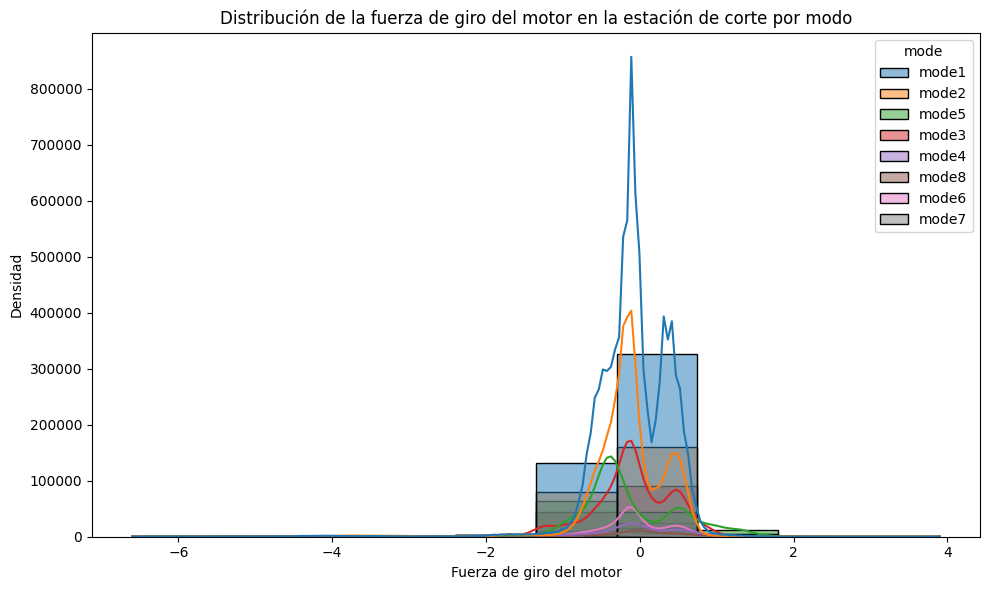

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    data = df1_copia,
    x = 'pCut::Motor_Torque',
    hue = 'mode',
    kde = True,
    alpha = 0.5,
    ax = ax,
    bins = 10
)

ax.set_title('Distribución de la fuerza de giro del motor en la estación de corte por modo')
ax.set_xlabel('Fuerza de giro del motor')
ax.set_ylabel('Densidad')
plt.tight_layout()
plt.show()

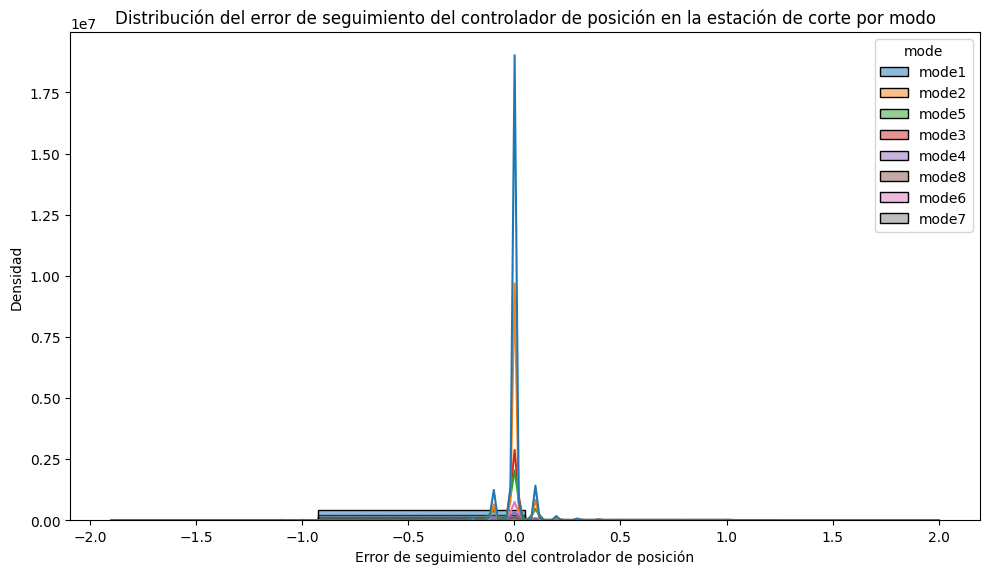

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    data = df1_copia,
    x = 'pCut::CTRL_Position_controller::Lag_error',
    hue = 'mode',
    kde = True,
    alpha = 0.5,
    ax = ax,
    bins = 4
)

ax.set_title('Distribución del error de seguimiento del controlador de posición en la estación de corte por modo')
ax.set_xlabel('Error de seguimiento del controlador de posición')
ax.set_ylabel('Densidad')
plt.tight_layout()
plt.show()

<Axes: ylabel='timestamp'>

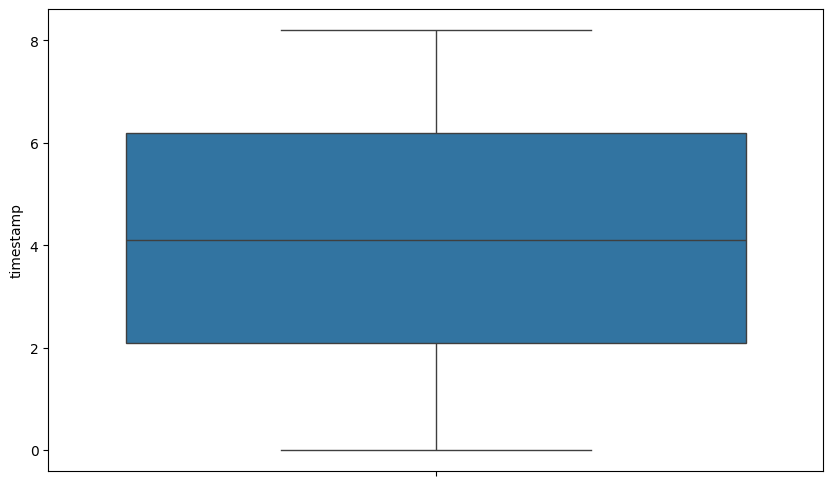

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1_copia,
    y='timestamp',
    ax=ax
)

<Axes: ylabel='pCut::Motor_Torque'>

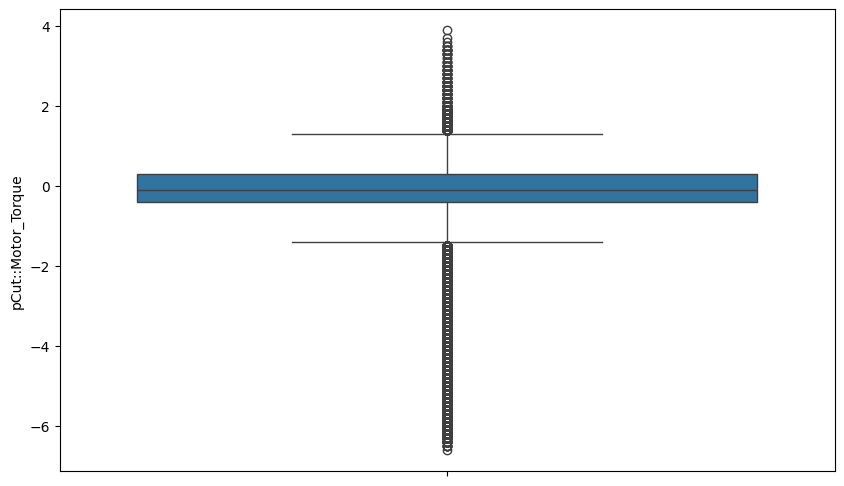

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1_copia,
    y='pCut::Motor_Torque',
    ax=ax
)

<Axes: ylabel='pCut::CTRL_Position_controller::Lag_error'>

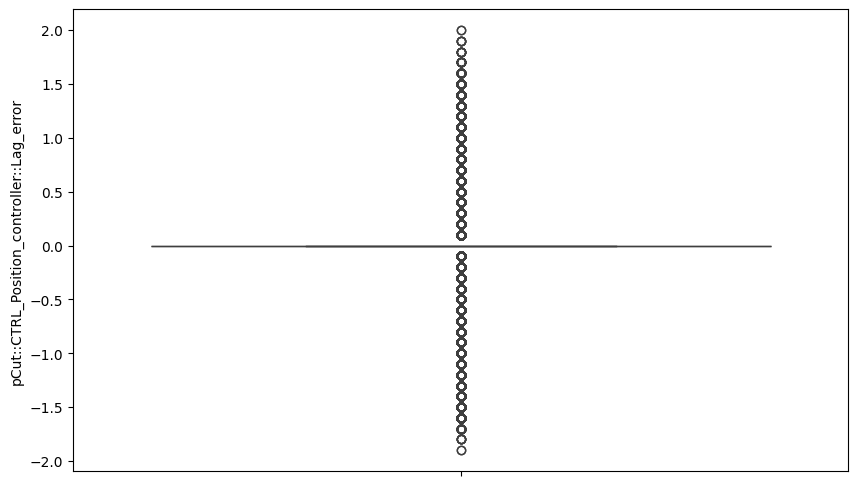

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1_copia,
    y='pCut::CTRL_Position_controller::Lag_error',
    ax=ax
)

<Axes: ylabel='pCut::CTRL_Position_controller::Actual_position'>

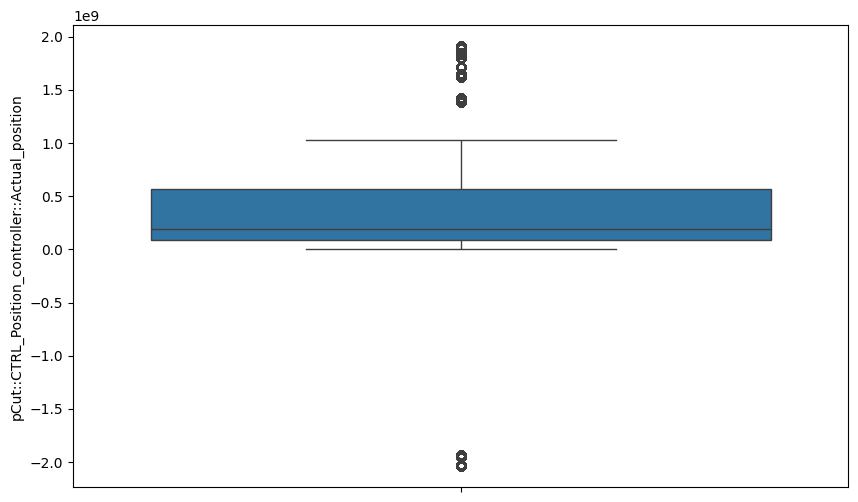

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1_copia,
    y='pCut::CTRL_Position_controller::Actual_position',
    ax=ax
)

<Axes: ylabel='pCut::CTRL_Position_controller::Actual_speed'>

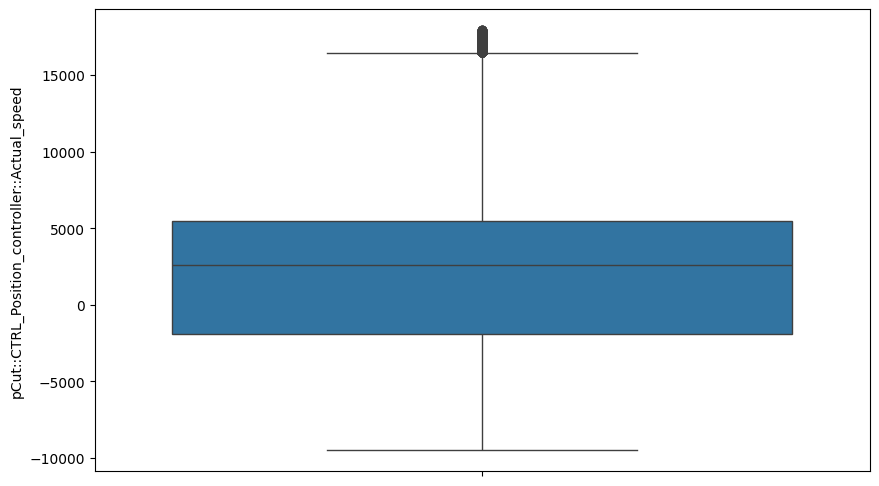

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1_copia,
    y='pCut::CTRL_Position_controller::Actual_speed',
    ax=ax
)

<Axes: ylabel='pSvolFilm::CTRL_Position_controller::Actual_position'>

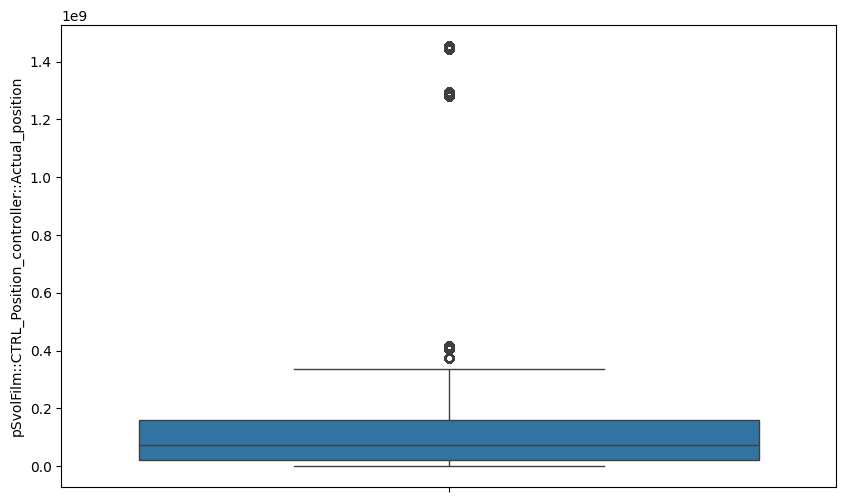

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1_copia,
    y='pSvolFilm::CTRL_Position_controller::Actual_position',
    ax=ax
)

<Axes: ylabel='pSvolFilm::CTRL_Position_controller::Actual_speed'>

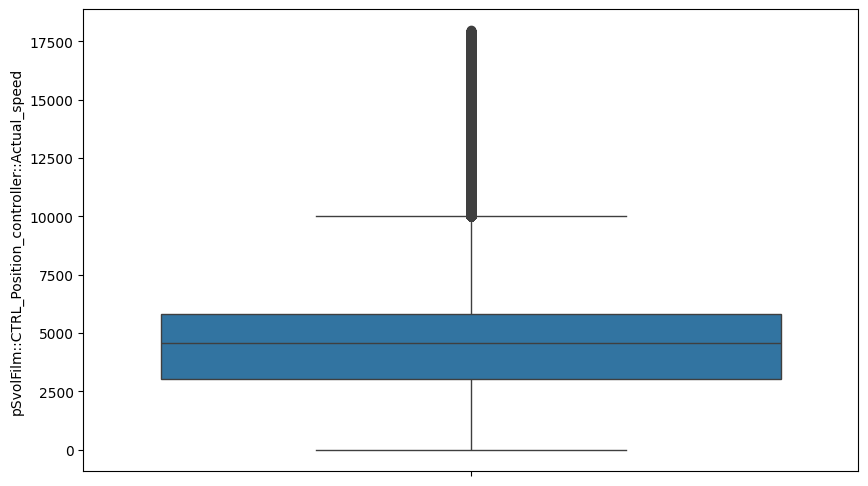

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1_copia,
    y='pSvolFilm::CTRL_Position_controller::Actual_speed',
    ax=ax
)

<Axes: ylabel='pSvolFilm::CTRL_Position_controller::Lag_error'>

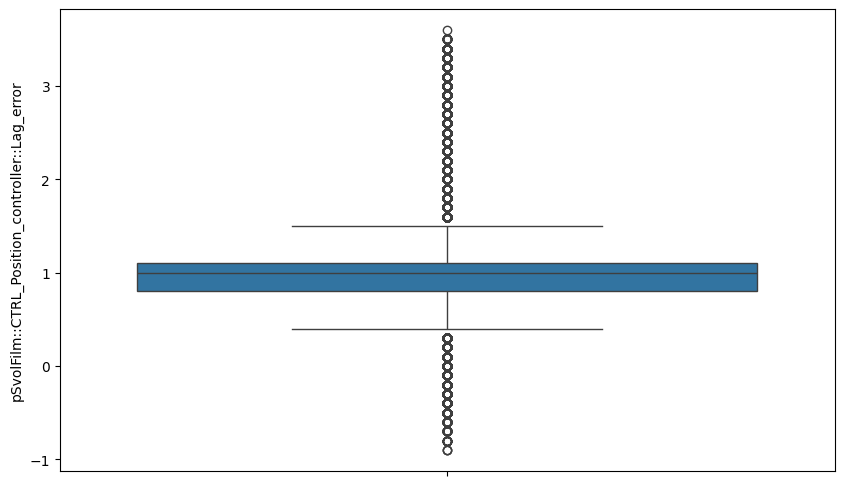

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1_copia,
    y='pSvolFilm::CTRL_Position_controller::Lag_error',
    ax=ax
)

<Axes: ylabel='pSpintor::VAX_speed'>

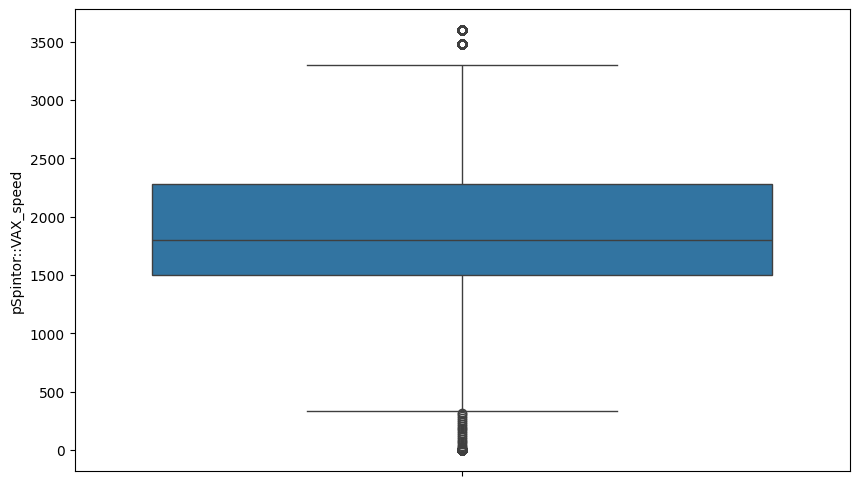

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1_copia,
    y='pSpintor::VAX_speed',
    ax=ax
)

<Axes: ylabel='month'>

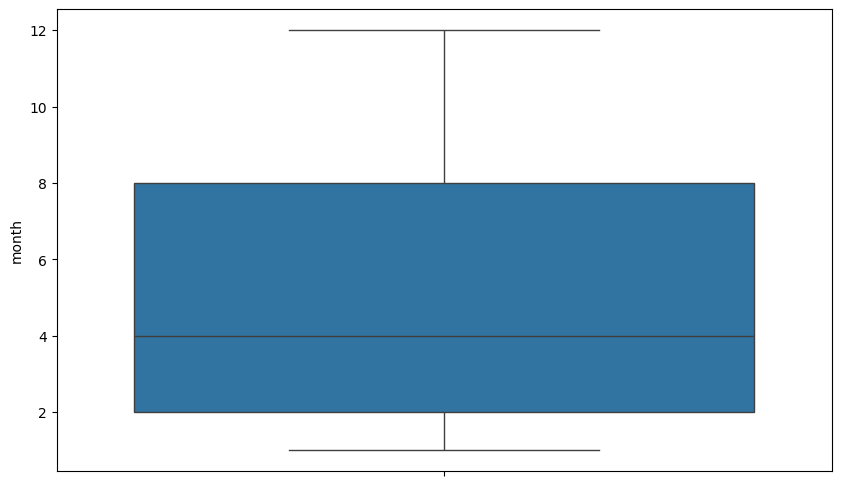

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1_copia,
    y='month',
    ax=ax
)

<Axes: ylabel='day'>

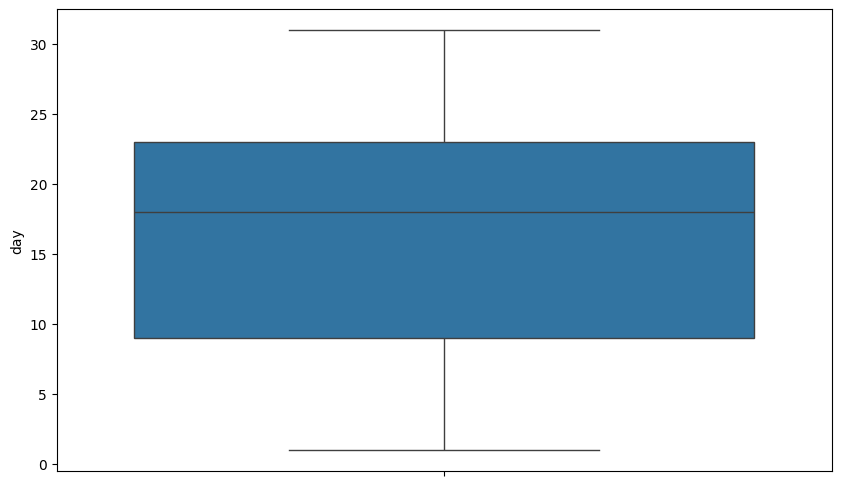

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1_copia,
    y='day',
    ax=ax
)

<Axes: ylabel='hour'>

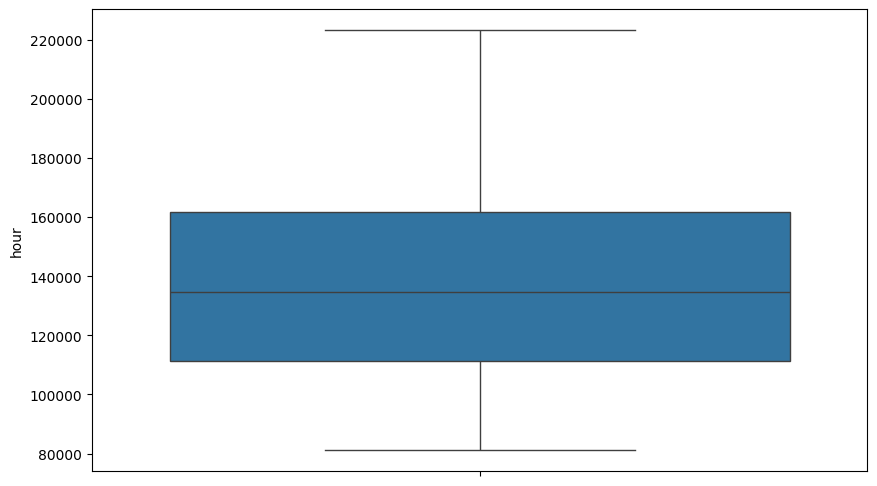

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1_copia,
    y='hour',
    ax=ax
)

<Axes: ylabel='sample_Number'>

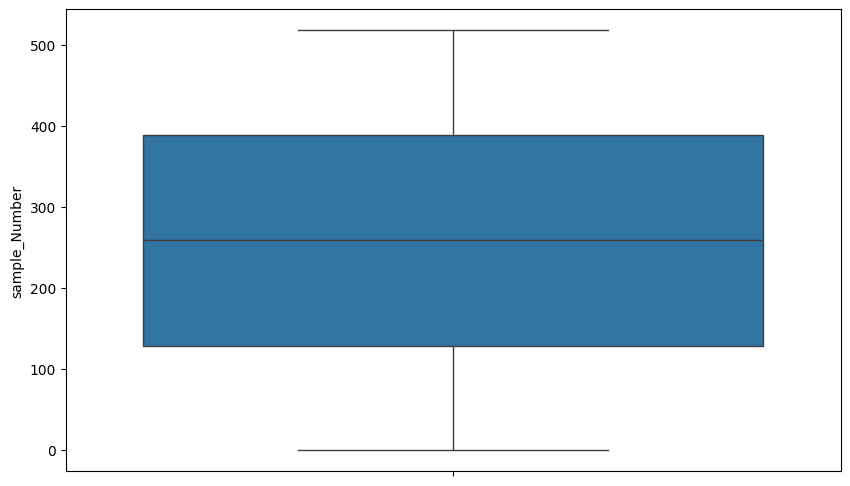

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df1_copia,
    y='sample_Number',
    ax=ax
)

In [30]:
df1_copia["averia"] = (
    (df1_copia["pCut::CTRL_Position_controller::Lag_error"] < 0) |
    (df1_copia["pSvolFilm::CTRL_Position_controller::Lag_error"] < 0) |
    (df1_copia["pCut::CTRL_Position_controller::Lag_error"] > 1.7) |
    (df1_copia["pSvolFilm::CTRL_Position_controller::Lag_error"] > 3)
).astype(int)

df1_copia["averia"].value_counts()

averia
0    953599
1    109313
Name: count, dtype: int64

In [31]:
df1_copia["s1"] = (
    (df1_copia["pCut::CTRL_Position_controller::Lag_error"] < 0) |
    (df1_copia["pCut::CTRL_Position_controller::Lag_error"] > 1.7)
).astype(int)

df1_copia["s1"].value_counts()

s1
0    959191
1    103721
Name: count, dtype: int64

In [32]:
df1_copia["s2"] = (
    (df1_copia["pSvolFilm::CTRL_Position_controller::Lag_error"] < 0) |
    (df1_copia["pSvolFilm::CTRL_Position_controller::Lag_error"] > 3)
).astype(int)

df1_copia["s2"].value_counts()

s2
0    1054172
1       8740
Name: count, dtype: int64

In [33]:
averia_filtrada = df1_copia[df1_copia["averia"]==0].copy()

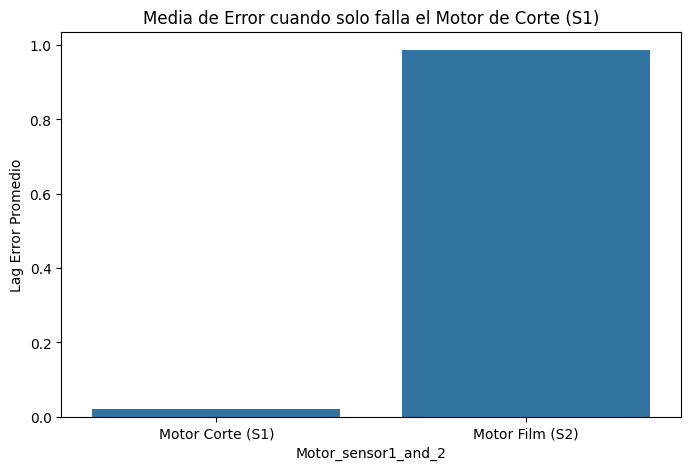

In [34]:
df1_copia1 = averia_filtrada[['pCut::CTRL_Position_controller::Lag_error', 
                    'pSvolFilm::CTRL_Position_controller::Lag_error']].mean().reset_index()
df1_copia1.columns = ['Motor_sensor1_and_2', 'Error_Medio']

plt.figure(figsize=(8, 5))
sns.barplot(data=df1_copia1, x='Motor_sensor1_and_2', y='Error_Medio')

plt.title('Media de Error cuando solo falla el Motor de Corte (S1)')
plt.ylabel('Lag Error Promedio')
plt.xticks([0, 1], ['Motor Corte (S1)', 'Motor Film (S2)'])
plt.show()

In [35]:
df1_copia1 = df1_copia.drop("mode", axis=1)
X = df1_copia1.drop("averia", axis=1)
X = X.drop("s1", axis=1)
X = X.drop("s2", axis=1)

X1 = np.array(df1_copia[['mode']])

y = df1_copia["averia"]

encoder = OrdinalEncoder(
    categories=[['mode0', 'mode1', 'mode2', 'mode3', 'mode4', 'mode5', 'mode6', 'mode7', 'mode8']]
)
X['mode'] = encoder.fit_transform(X1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-1.73436265e+00,  5.26864093e-01,  1.32801622e-03, ...,
        -1.72871268e+00, -1.21852688e+00, -8.02535631e-01],
       [-1.73436265e+00,  6.91191003e-01,  1.32801622e-03, ...,
        -1.72871268e+00, -1.21852688e+00, -8.02535631e-01],
       [-1.73436265e+00,  6.91191003e-01,  1.32801622e-03, ...,
        -1.72871268e+00, -1.21852688e+00, -8.02535631e-01],
       ...,
       [ 1.73261108e+00, -1.30443544e-01,  1.32801622e-03, ...,
         1.73040170e+00,  1.92171865e+00, -1.96325639e-01],
       [ 1.73261108e+00, -4.59097362e-01,  1.32801622e-03, ...,
         1.73040170e+00,  1.92171865e+00, -1.96325639e-01],
       [ 1.73261108e+00, -2.94770453e-01,  1.32801622e-03, ...,
         1.73040170e+00,  1.92171865e+00, -1.96325639e-01]],
      shape=(1062912, 15))

In [36]:
pca = PCA(n_components=9, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Forma original: {X.shape}")
print(f"Forma reducida: {X_pca.shape}")
print(f"Varianza explicada por componente: {pca.explained_variance_ratio_.round(3)}")
print(f"Varianza acumulada total: {pca.explained_variance_ratio_.sum():.3f}")

Forma original: (1062912, 15)
Forma reducida: (1062912, 9)
Varianza explicada por componente: [0.229 0.153 0.121 0.088 0.077 0.068 0.067 0.052 0.046]
Varianza acumulada total: 0.901


In [37]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [38]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [39]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [40]:
y_pred = model.predict(X_test)

In [41]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión del Random Forest: {accuracy * 100:.2f}%')

Precisión del Random Forest: 100.00%


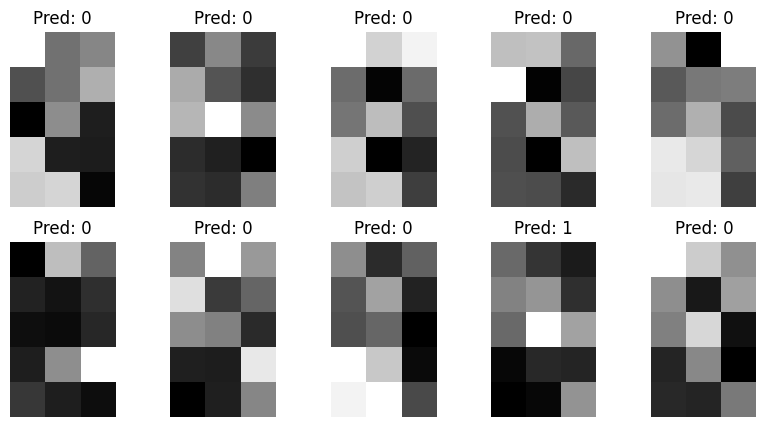

In [45]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(5, 3), cmap="gray")
    ax.set_title(f'Pred: {y_pred[i]}')
    ax.axis("off")
plt.show()